In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
df = pd.read_csv("marketing_data_cleaned.csv")

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        2240 non-null   int64  
 1   Year_Birth                2240 non-null   int64  
 2   Education                 2240 non-null   object 
 3   Marital_Status            2240 non-null   object 
 4   Kidhome                   2240 non-null   int64  
 5   Teenhome                  2240 non-null   int64  
 6   Dt_Customer               2240 non-null   object 
 7   Recency                   2240 non-null   int64  
 8   MntWines                  2240 non-null   int64  
 9   MntFruits                 2240 non-null   int64  
 10  MntMeatProducts           2240 non-null   int64  
 11  MntFishProducts           2240 non-null   int64  
 12  MntSweetProducts          2240 non-null   int64  
 13  MntGoldProds              2240 non-null   int64  
 14  NumDeals

In [3]:
df.shape

(2240, 33)

# THE CUSTOMERS

In [4]:
#AGE Distribution of customers

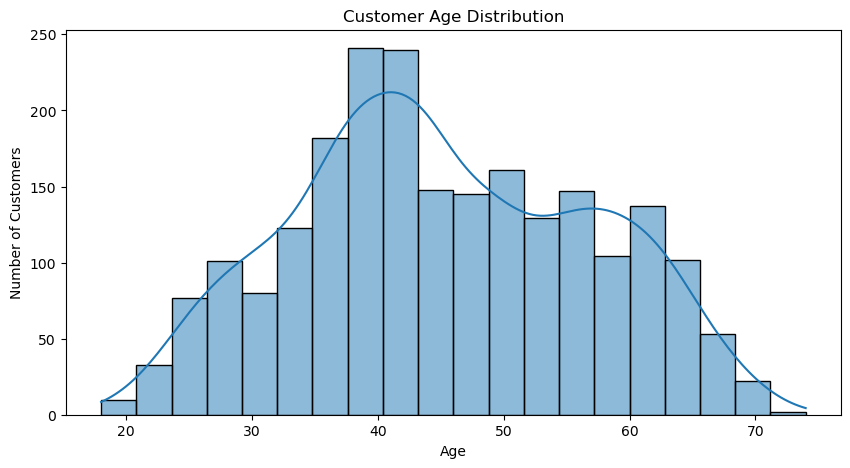

In [5]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Age"].dropna(),
    bins=20,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

In [6]:
bins = [0, 25, 35, 45, 55, 65, 100]

labels = [
    "Under 25",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    right=False
)

In [7]:
df["Age_Group"].value_counts().sort_index()

Age_Group
Under 25     61
25-34       363
35-44       740
45-54       506
55-64       460
65+         107
Name: count, dtype: int64

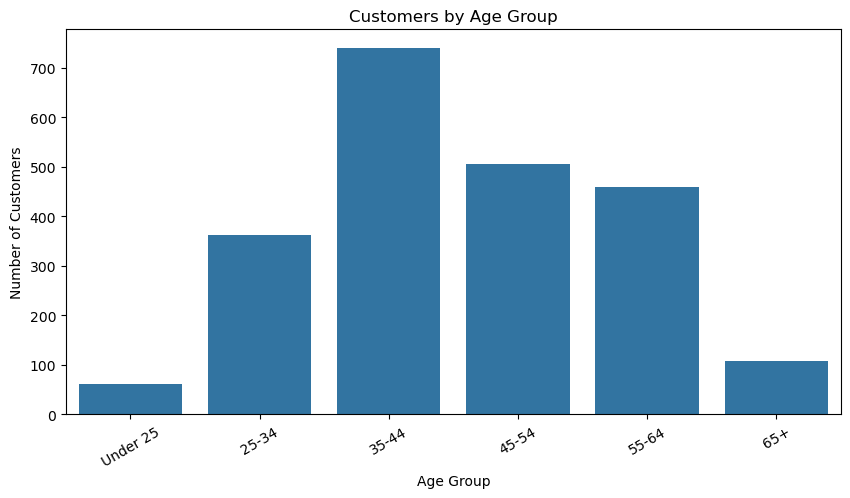

In [8]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Age_Group"
)

plt.title("Customers by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.show()

In [9]:
#INCOME

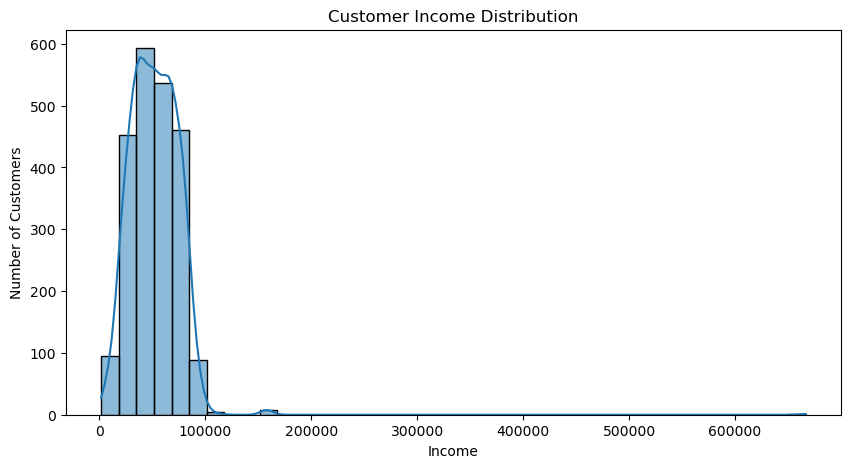

In [10]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Income"],
    bins=40,
    kde=True
)

plt.title("Customer Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Customers")
plt.show()

In [11]:
df["Income"].describe()

count      2240.000000
mean      52237.975446
std       25037.955891
min        1730.000000
25%       35538.750000
50%       51381.500000
75%       68289.750000
max      666666.000000
Name: Income, dtype: float64

In [12]:
#Customer spending

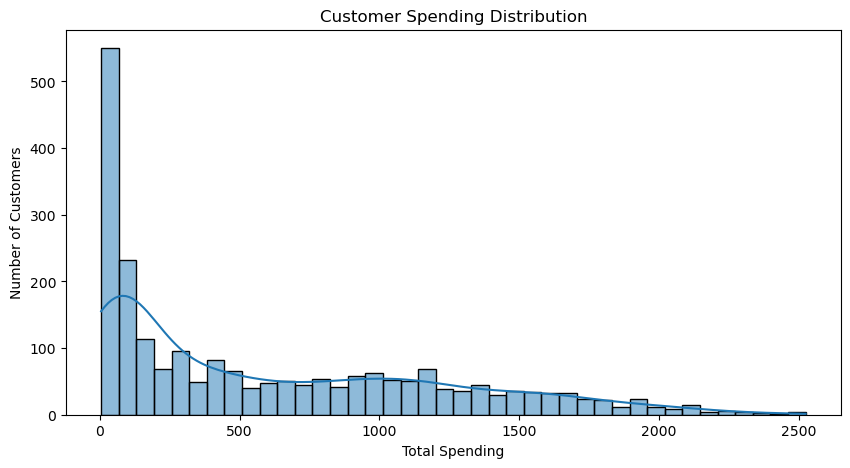

In [13]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Total_Spending"],
    bins=40,
    kde=True
)

plt.title("Customer Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.show()

In [14]:
df["Total_Spending"].describe()

count    2240.000000
mean      605.798214
std       602.249288
min         5.000000
25%        68.750000
50%       396.000000
75%      1045.500000
max      2525.000000
Name: Total_Spending, dtype: float64

In [15]:
#Which products generate the most spending?

In [16]:
product_spending = {
    "Wines": df["MntWines"].sum(),
    "Fruits": df["MntFruits"].sum(),
    "Meat": df["MntMeatProducts"].sum(),
    "Fish": df["MntFishProducts"].sum(),
    "Sweets": df["MntSweetProducts"].sum(),
    "Gold": df["MntGoldProds"].sum()
}

product_spending

{'Wines': np.int64(680816),
 'Fruits': np.int64(58917),
 'Meat': np.int64(373968),
 'Fish': np.int64(84057),
 'Sweets': np.int64(60621),
 'Gold': np.int64(98609)}

In [17]:
product_df = pd.DataFrame(
    list(product_spending.items()),
    columns=["Product", "Total_Spending"]
)

product_df = product_df.sort_values(
    "Total_Spending",
    ascending=False
)

product_df

,Product,Total_Spending
0,Wines,680816
2,Meat,373968
5,Gold,98609
3,Fish,84057
4,Sweets,60621
1,Fruits,58917


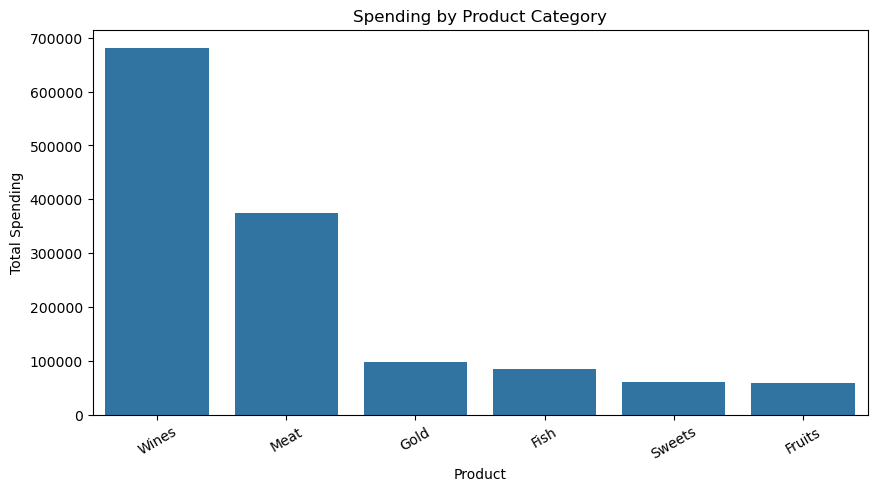

In [18]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=product_df,
    x="Product",
    y="Total_Spending"
)

plt.title("Spending by Product Category")
plt.xlabel("Product")
plt.ylabel("Total Spending")
plt.xticks(rotation=30)
plt.show()

In [19]:
#Which purchasing channel is strongest?

In [20]:
channel_purchases = {
    "Web": df["NumWebPurchases"].sum(),
    "Catalog": df["NumCatalogPurchases"].sum(),
    "Store": df["NumStorePurchases"].sum()
}

channel_purchases

{'Web': np.int64(9150), 'Catalog': np.int64(5963), 'Store': np.int64(12970)}

In [21]:
channel_df = pd.DataFrame(
    list(channel_purchases.items()),
    columns=["Channel", "Purchases"]
)

channel_df

,Channel,Purchases
0,Web,9150
1,Catalog,5963
2,Store,12970


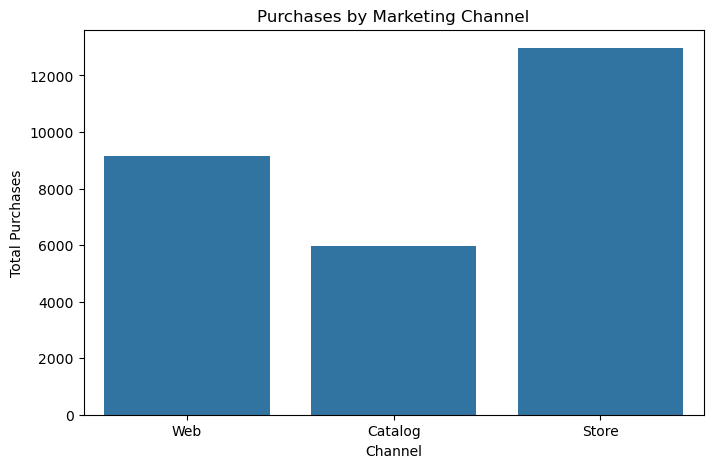

In [22]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=channel_df,
    x="Channel",
    y="Purchases"
)

plt.title("Purchases by Marketing Channel")
plt.xlabel("Channel")
plt.ylabel("Total Purchases")
plt.show()

In [23]:
#Web engagement vs web purchases

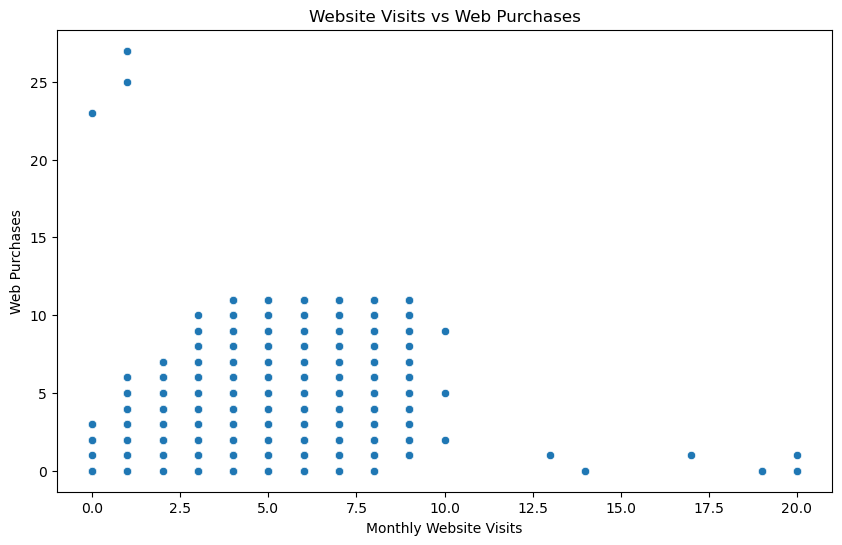

In [24]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="NumWebVisitsMonth",
    y="NumWebPurchases"
)

plt.title("Website Visits vs Web Purchases")
plt.xlabel("Monthly Website Visits")
plt.ylabel("Web Purchases")
plt.show()

In [25]:
df["NumWebVisitsMonth"].corr(
    df["NumWebPurchases"]
)

np.float64(-0.05584633165982068)

In [26]:
#Campaign response analysis

In [27]:
campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

response_rates = df[campaign_cols].mean() * 100

response_rates

AcceptedCmp1     6.428571
AcceptedCmp2     1.339286
AcceptedCmp3     7.276786
AcceptedCmp4     7.455357
AcceptedCmp5     7.276786
Response        14.910714
dtype: float64

In [28]:
campaign_df = response_rates.reset_index()

campaign_df.columns = [
    "Campaign",
    "Response_Rate"
]

campaign_df

,Campaign,Response_Rate
0,AcceptedCmp1,6.428571
1,AcceptedCmp2,1.339286
2,AcceptedCmp3,7.276786
3,AcceptedCmp4,7.455357
4,AcceptedCmp5,7.276786
5,Response,14.910714


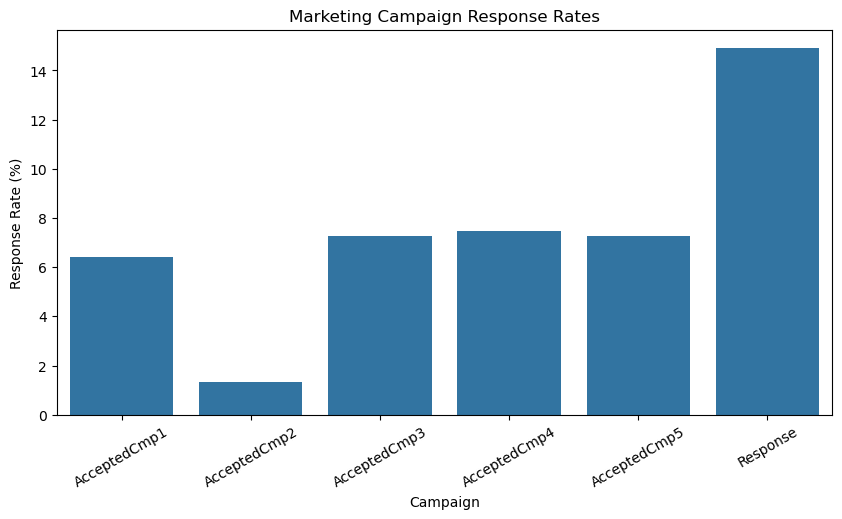

In [29]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=campaign_df,
    x="Campaign",
    y="Response_Rate"
)

plt.title("Marketing Campaign Response Rates")
plt.xlabel("Campaign")
plt.ylabel("Response Rate (%)")
plt.xticks(rotation=30)
plt.show()

In [30]:
#RESPONDERS VS NON-RESPONDERS

In [31]:
df.groupby("Response")["Total_Spending"].mean()

Response
0    538.929171
1    987.392216
Name: Total_Spending, dtype: float64

In [32]:
response_spending = df.groupby(
    "Response"
)["Total_Spending"].mean().reset_index()

response_spending["Response"] = response_spending[
    "Response"
].map({
    0: "Non-Responder",
    1: "Responder"
})

response_spending

,Response,Total_Spending
0,Non-Responder,538.929171
1,Responder,987.392216


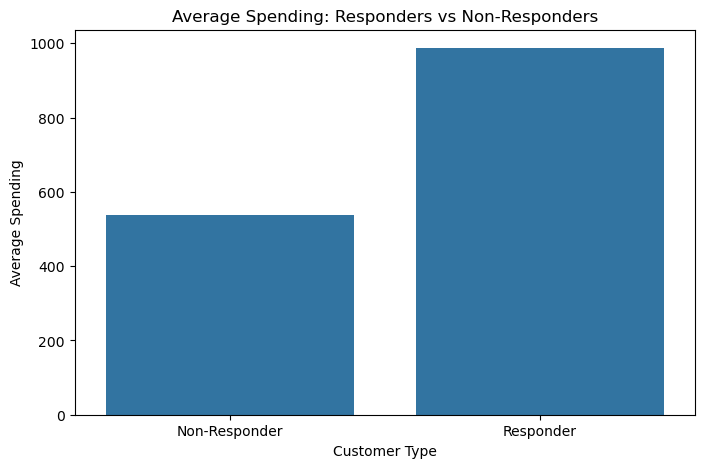

In [33]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=response_spending,
    x="Response",
    y="Total_Spending"
)

plt.title("Average Spending: Responders vs Non-Responders")
plt.xlabel("Customer Type")
plt.ylabel("Average Spending")
plt.show()

In [34]:
#CAMPAIGN RESPONCE BY AGE GROUP

In [35]:
age_response = df.groupby(
    "Age_Group",
    observed=False
)["Response"].mean() * 100

age_response

Age_Group
Under 25    22.950820
25-34       18.457300
35-44       14.189189
45-54       12.450593
55-64       12.826087
65+         24.299065
Name: Response, dtype: float64

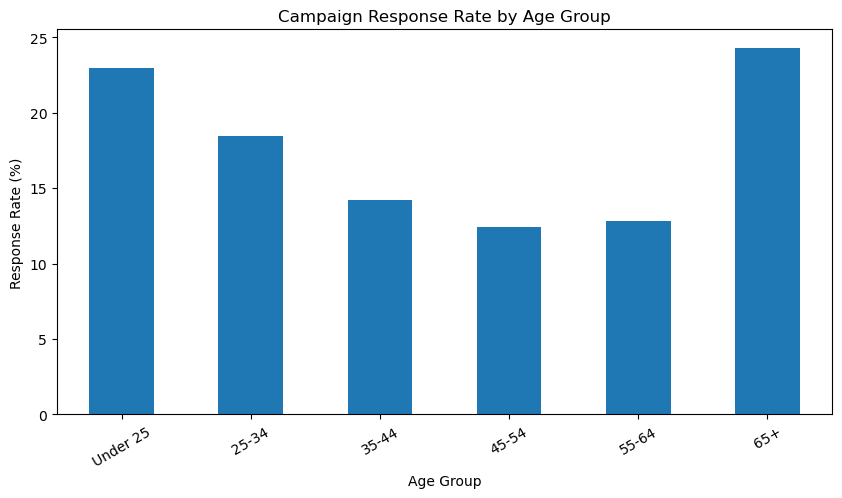

In [36]:
plt.figure(figsize=(10, 5))

age_response.plot(
    kind="bar"
)

plt.title("Campaign Response Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Response Rate (%)")
plt.xticks(rotation=30)
plt.show()

In [37]:
#Campaign response by customer segment

In [38]:
segment_response = df.groupby(
    "Customer_Segment",
    observed=False
)["Response"].mean() * 100

segment_response

Customer_Segment
High Value      24.899598
Low Value        7.486631
Medium Value    12.348993
Name: Response, dtype: float64

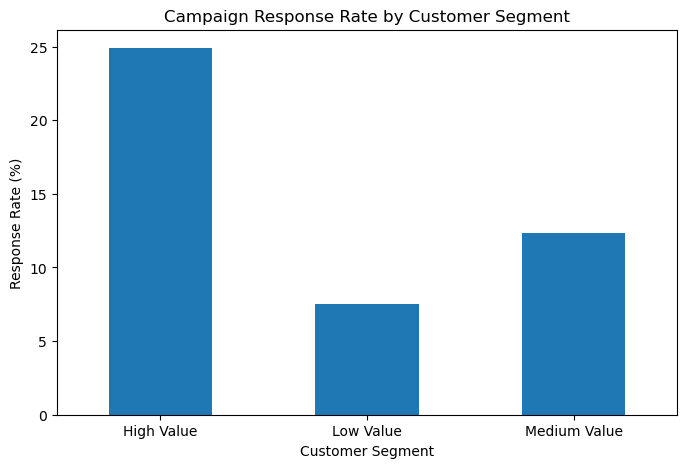

In [39]:
plt.figure(figsize=(8, 5))

segment_response.plot(
    kind="bar"
)

plt.title("Campaign Response Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Response Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [40]:
#Income vs spending

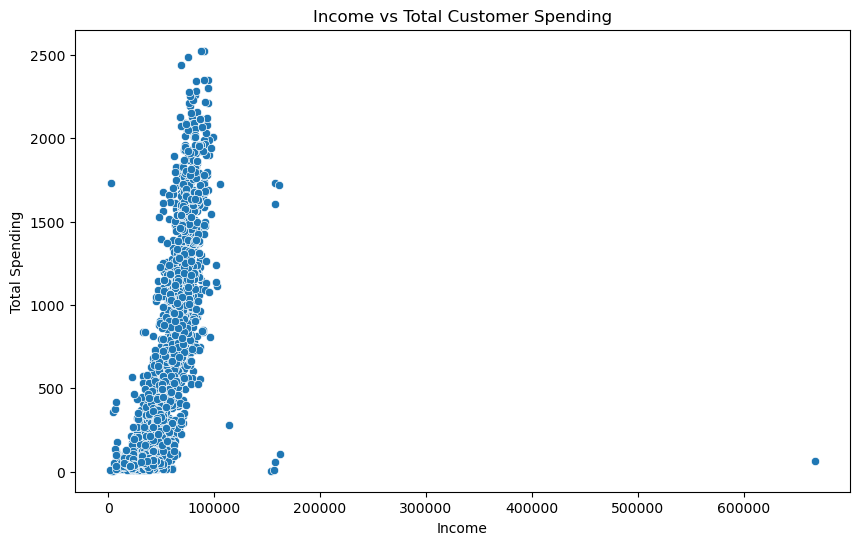

In [41]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spending"
)

plt.title("Income vs Total Customer Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.show()

In [42]:
df["Income"].corr(
    df["Total_Spending"]
)

np.float64(0.6647748566757213)

In [43]:
#correlation heatmap

In [44]:
important_cols = [
    "Income",
    "Age",
    "Recency",
    "Total_Spending",
    "Total_Purchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Total_Campaign_Responses",
    "Response"
]

corr = df[important_cols].corr()

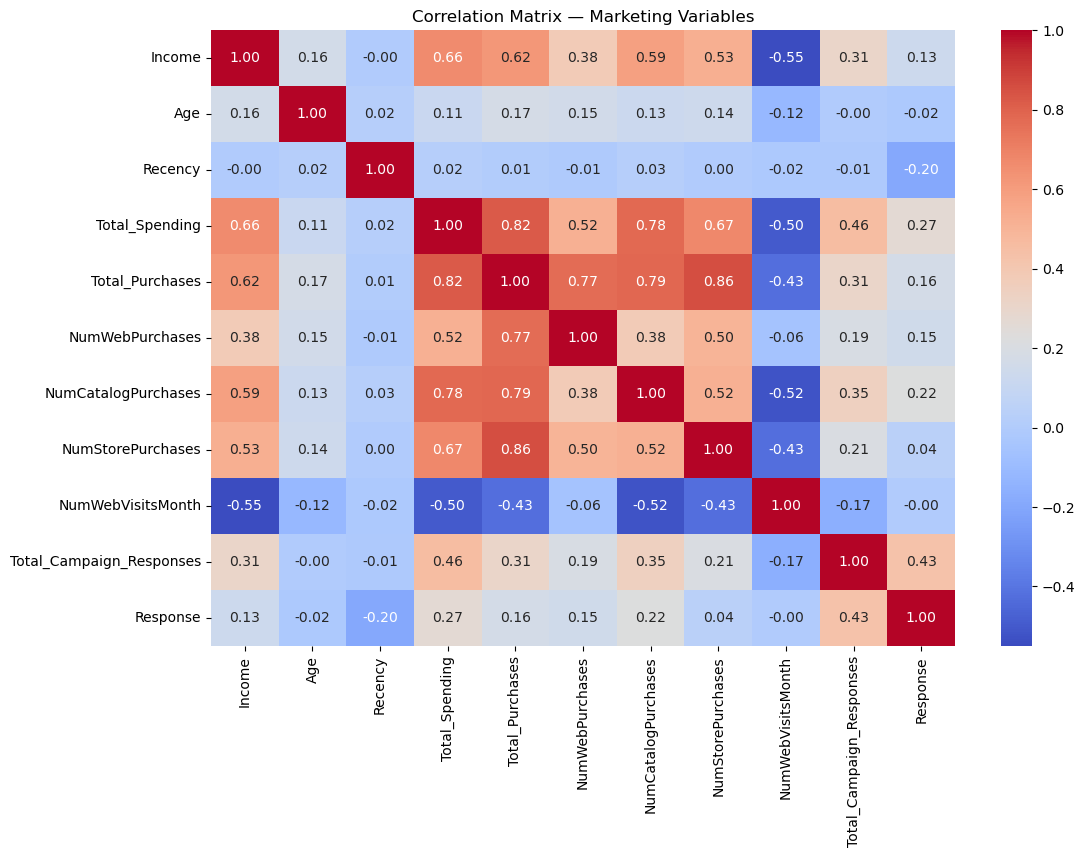

In [45]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix — Marketing Variables")
plt.show()

In [46]:
#outlier

In [47]:
df[df["Income"] > 200000][
    ["ID", "Year_Birth", "Income", "Education",
     "Marital_Status", "Total_Spending", "Response"]
]

,ID,Year_Birth,Income,Education,Marital_Status,Total_Spending,Response
527,9432,1977,666666.0,Graduation,Together,62,0


In [48]:
df[df["Income"] > 200000].shape

(1, 34)

In [49]:
df["Income_Clean"] = df["Income"]

df.loc[df["Income_Clean"] > 200000, "Income_Clean"] = np.nan

In [50]:
df[df["Income_Clean"].isna()][
    ["ID", "Income", "Income_Clean"]
]

,ID,Income,Income_Clean
527,9432,666666.0,NaN


In [51]:
df["Income_Clean"].describe()

count      2239.000000
mean      51963.554712
std       21410.672116
min        1730.000000
25%       35533.500000
50%       51381.500000
75%       68277.500000
max      162397.000000
Name: Income_Clean, dtype: float64

In [52]:
df["Income_Clean"].corr(df["Total_Spending"])

np.float64(0.7892957853161522)